In [1]:
import numpy as np
import torch
from torch import nn
import tqdm

In [2]:
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 229kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.05MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.3MB/s]


106
12
40


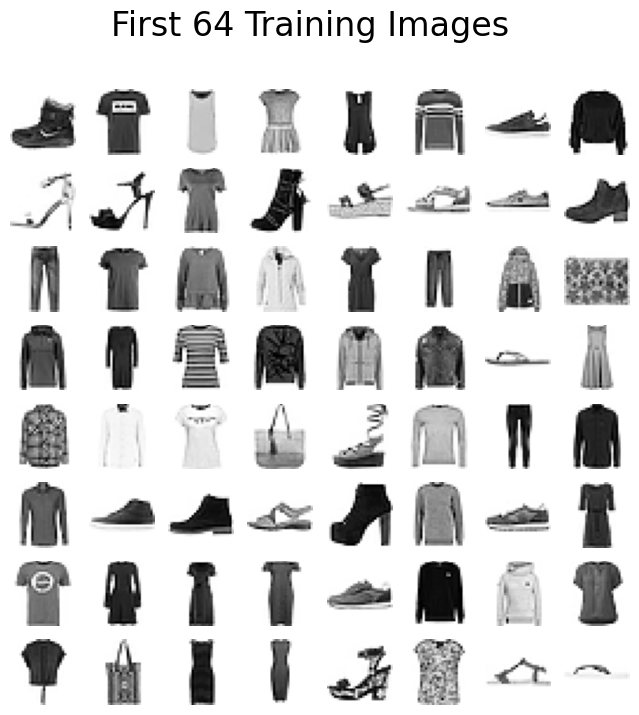

In [3]:
# Use the following code to load and normalize the dataset for training and testing
# It will downlad the dataset into data subfolder (change to your data folder name)
train_dataset = torchvision.datasets.FashionMNIST('data/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.2860,), (0.3530,))
                             ]))

test_dataset = torchvision.datasets.FashionMNIST('data/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.2860,), (0.3530,))
                             ]))


# Use the following code to create a validation set of 10%
train_indices, val_indices, _, _ = train_test_split(
    range(len(train_dataset)),
    train_dataset.targets,
    stratify=train_dataset.targets,
    test_size=0.1,
)

# Generate training and validation subsets based on indices
train_split = Subset(train_dataset, train_indices)
val_split = Subset(train_dataset, val_indices)


# set batches sizes
train_batch_size = 512 #Define train batch size
test_batch_size  = 256 #Define test batch size (can be larger than train batch size)


# Define dataloader objects that help to iterate over batches and samples for
# training, validation and testing
train_batches = DataLoader(train_split, batch_size=train_batch_size, shuffle=True)
val_batches = DataLoader(val_split, batch_size=train_batch_size, shuffle=True)
test_batches = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True)

num_train_batches=len(train_batches)
num_val_batches=len(val_batches)
num_test_batches=len(test_batches)


print(num_train_batches)
print(num_val_batches)
print(num_test_batches)


#Sample code to visulaize the first sample in first 16 batches

# batch_num = 0
# for train_features, train_labels in train_batches:

#     if batch_num == 16:
#         break    # break here

#     batch_num = batch_num +1
#     print(f"Feature batch shape: {train_features.size()}")
#     print(f"Labels batch shape: {train_labels.size()}")

#     img = train_features[0].squeeze()
#     label = train_labels[0]
#     plt.imshow(img, cmap="gray")
#     plt.show()
#     print(f"Label: {label}")



# Sample code to plot N^2 images from the dataset
def plot_images(XX, N, title):
    fig, ax = plt.subplots(N, N, figsize=(8, 8))

    for i in range(N):
      for j in range(N):
        ax[i,j].imshow(XX[(N)*i+j], cmap="Greys")
        ax[i,j].axis("off")
    fig.suptitle(title, fontsize=24)

plot_images(train_dataset.data[:64], 8, "First 64 Training Images" )



In [62]:
#Define your (As Cool As It Gets) Fully Connected Neural Network
class Network(nn.Module):
    #Initialize model layers, add additional arguments to adjust
    def __init__(self, input_dim, output_dim, hidden_dim, num_hidden_layers, init_type, batch_norm_true):
        super().__init__()
        #Define the network layer(s) and activation function(s)
        self.batch_norm_true = batch_norm_true
        self.batch_norms = nn.ModuleList()
        self.layers = nn.ModuleList()
        self.relu = nn.ReLU()

        self.layers.append(nn.Linear(input_dim, hidden_dim))
        if self.batch_norm_true:
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))

        for _ in range(num_hidden_layers - 1):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
            if self.batch_norm_true:
                self.batch_norms.append(nn.BatchNorm1d(hidden_dim))

        self.output_layer = nn.Linear(hidden_dim, output_dim)
        self._initialize_weights(init_type)

    def _initialize_weights(self, init_type):
        all_layers = list(self.layers) + [self.output_layer]
        for layer in all_layers:
            if init_type == 'random_normal':
                nn.init.normal_(layer.weight, mean=0, std=0.01)
            elif init_type == 'xavier_normal':
                nn.init.xavier_normal_(layer.weight)
            elif init_type == 'kaiming_uniform':
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
            nn.init.zeros_(layer.bias)

    def forward(self, input):
        #Define how your model propagates the input through the network
        for i, layer in enumerate(self.layers):
            input = layer(input)
            if self.batch_norm_true:
                input = self.batch_norms[i](input)
            input = self.relu(input)
        return self.output_layer(input)


In [70]:
# Initialize neural network model with input, output and hidden layer dimensions
model = Network(input_dim = 784, output_dim = 10, hidden_dim = 512, num_hidden_layers = 2, init_type='kaiming_uniform', batch_norm_true=True)

# Define the learning rate and epochs number
learning_rate = 0.05
epochs = 30

train_loss_list = np.zeros((epochs,))
validation_accuracy_list = np.zeros((epochs,))

# Define loss function  and optimizer
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Iterate over epochs, batches with progress bar and train+ validate the Network
# Track the loss and validation accuracy
for epoch in tqdm.trange(epochs):
    epoch_loss = 0
    # Network Training
    for train_features, train_labels in train_batches:
        # Set model into training mode
        model.train()
        # Reshape images into a vector
        train_features = train_features.reshape(-1, 28*28)
        # Reset gradients, Calculate training loss on model
        optimizer.zero_grad()
        train_outputs = model(train_features)
        train_loss = loss_func(train_outputs, train_labels)
        # Perfrom optimization, back propagation
        train_loss.backward()
        optimizer.step()
        epoch_loss += train_loss.item()

    # Record loss for the epoch
    train_loss_list[epoch] = epoch_loss/num_train_batches

    # Network Validation
    val_acc = 0.0
    for val_features, val_labels in val_batches:
        # Telling PyTorch we aren't passing inputs to network for training purpose
        with torch.no_grad():
            model.eval()
            # Reshape validation images into a vector
            val_features = val_features.reshape(-1, 28*28)
            # Compute validation outputs (targets)
            val_outputs = model(val_features)
            # and compute accuracy
            predictions = torch.argmax(val_outputs, dim=1)
            val_acc += (predictions == val_labels).float().mean().item()

    validation_accuracy_list[epoch] = val_acc/num_val_batches*100
    # Record accuracy for the epoch; print training loss, validation accuracy
    print("Epoch: "+ str(epoch) + "; Train Loss: " + str(train_loss_list[epoch]) + "; Validation Accuracy:" + str(val_acc/num_val_batches*100) + '%')

  3%|▎         | 1/30 [00:17<08:25, 17.42s/it]

Epoch: 0; Train Loss: 14.559243819623623; Validation Accuracy:58.49680155515671%


  7%|▋         | 2/30 [00:35<08:24, 18.00s/it]

Epoch: 1; Train Loss: 1.0287194111437168; Validation Accuracy:73.93002708752951%


 10%|█         | 3/30 [00:53<07:58, 17.72s/it]

...

Epoch: 27; Train Loss: 2.4477850254976525; Validation Accuracy:17.060829947392143%


 97%|█████████▋| 29/30 [08:54<00:18, 18.76s/it]

Epoch: 28; Train Loss: 2.0296651282400453; Validation Accuracy:18.804489324490227%


100%|██████████| 30/30 [09:13<00:00, 18.44s/it]

Epoch: 29; Train Loss: 2.115633190802808; Validation Accuracy:18.022531643509865%


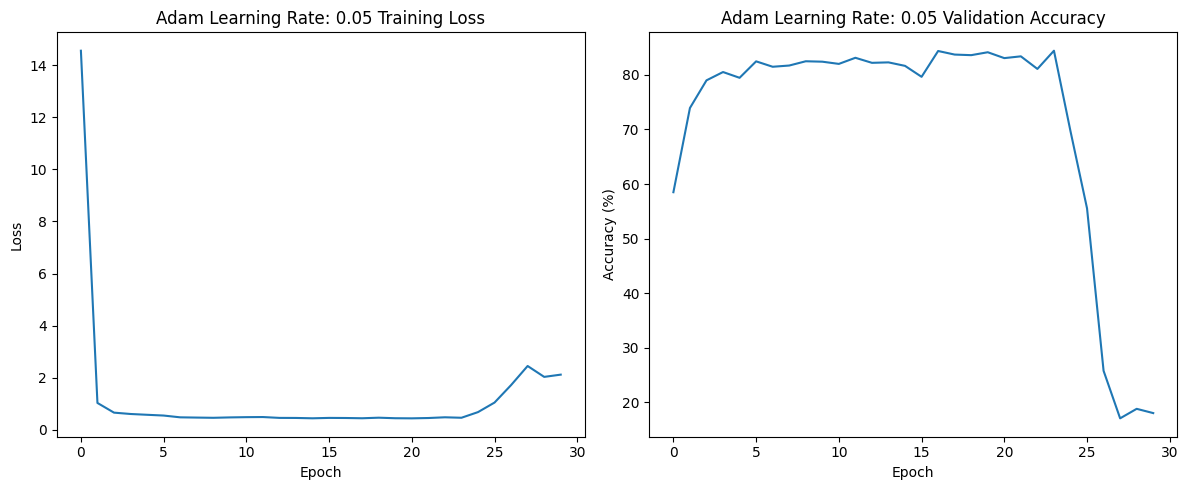

In [71]:
# Plot training loss and validation accuracy throughout the training epochs
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(epochs), train_loss_list)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(range(epochs), validation_accuracy_list)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()

In [72]:
#Calculate accuracy on test set
test_acc = 0.0

# Telling PyTorch we aren't passing inputs to network for training purpose
with torch.no_grad():

    for test_features, test_labels in test_batches:

        model.eval()
        # Reshape test images into a vector
        test_features = test_features.reshape(-1, 28*28)

        # Compute test outputs (targets)
        test_outputs = model(test_features)
        # and compute accuracy
        predictions = torch.argmax(test_outputs, dim=1)
        batch_accuracy = (predictions == test_labels).float().mean().item()
        test_acc += batch_accuracy

    # Compute total (mean) accuracy
    # Report total (mean) accuracy, can also compute std based on batches
    print("Test Accuracy: " + str(test_acc/num_test_batches*100) + '%')

Test Accuracy: 17.94921875%
